# Import Dependcies

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys
import functions
import preprocess

In [7]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

In [8]:
from utils import data_cleaning 
from models import A4_model
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.model_selection import cross_val_score

# Data Cleaning

In [9]:
full_path = os.path.join(parent_dir,  "data/raw/bank_customers_train.csv")
df_encoded, df_scaled = preprocess.prepare_data(full_path)

Encoded data saved to ../data/processed/bank_customers_train_encoded.csv
Scaled data saved to ../data/processed/bank_customers_train_scaled.csv


<Axes: >

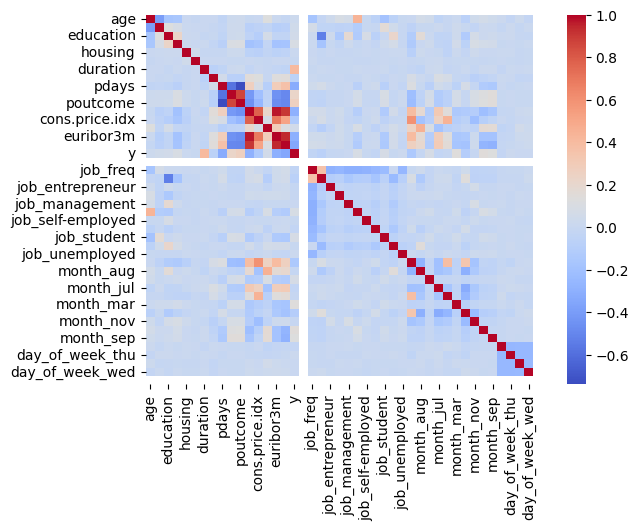

In [10]:
corr_matrix = df_scaled.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

## Logistic Regression

In [11]:
X = df_encoded.drop(columns=['y', 'age_bin'])  # Features
y = df_encoded['y']  # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Logistic Regression works better with normalized data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Find the best Logistic Regression model parameters
best_model = A4_model.find_best_logistic_regression_params(X_train, y_train)

# 5. Train and evaluate the model
y_test_result, y_pred = A4_model.train_and_evaluate_logistic_regression(best_model, X_train, y_train, X_test, y_test)

Best Parameters: {'C': np.float64(73.92266140516048), 'penalty': 'l1', 'solver': 'liblinear'}
Test Accuracy: 0.9113645733131785
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      6472
           1       0.64      0.45      0.53       805

    accuracy                           0.91      7277
   macro avg       0.79      0.71      0.74      7277
weighted avg       0.90      0.91      0.90      7277



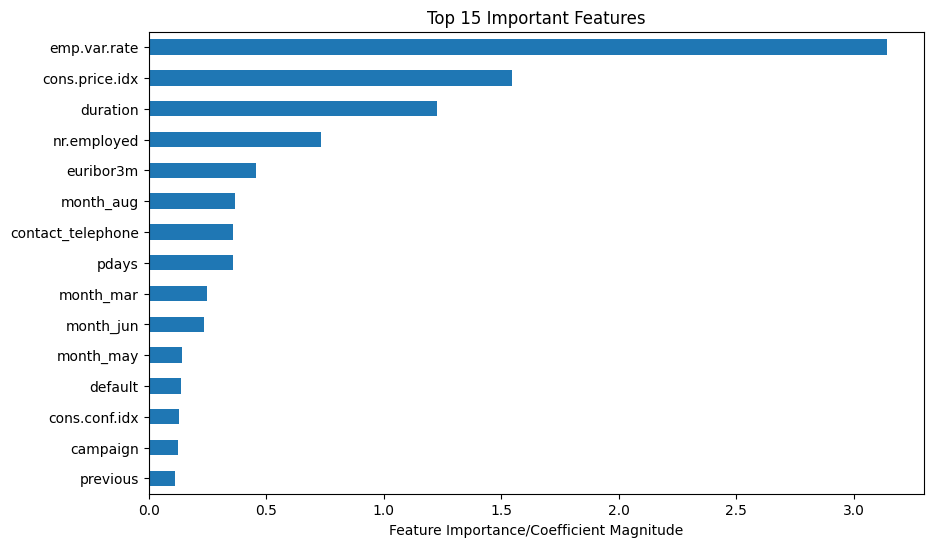

In [12]:
functions.plot_top_features(best_model, X)

## Random Forest

In [13]:
best_rf = A4_model.find_best_random_forest_params(X_train, y_train)
y_pred, y_proba, cv_accuracy = A4_model.train_and_evaluate_random_forest(best_rf, X_train, y_train, X_test, y_test)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': 'balanced_subsample'}
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93      6472
           1       0.49      0.87      0.63       805

    accuracy                           0.89      7277
   macro avg       0.74      0.88      0.78      7277
weighted avg       0.93      0.89      0.90      7277

ROC-AUC Score: 0.948
Cross-Validation Accuracy: 0.887


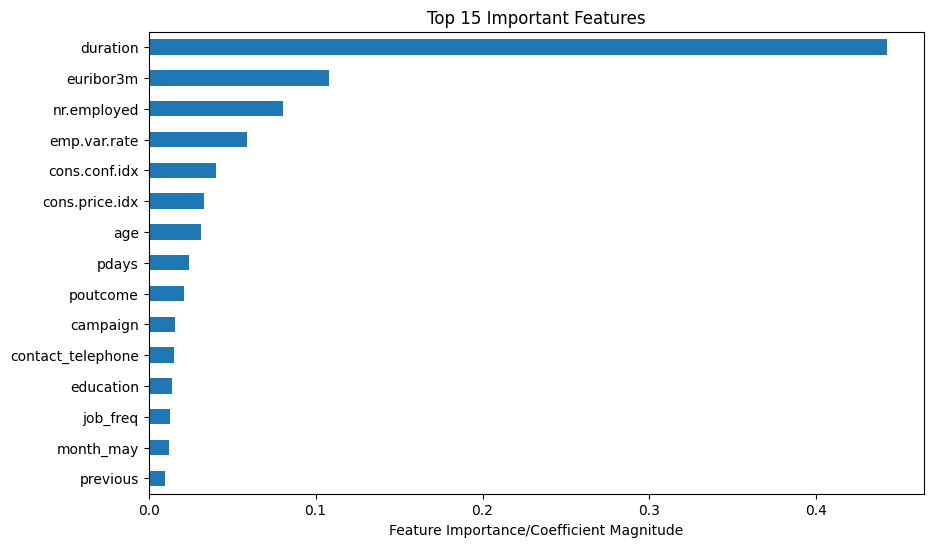

In [14]:
functions.plot_top_features(best_rf, X) 